In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

# Herramientas de validación y preprocesamiento
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from category_encoders import TargetEncoder
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Modelos
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# Carga del dataset
PATH_DATASET = '../data/4_YouTubeDataset_withChannelElapsed.csv'
df = pd.read_csv(PATH_DATASET)

# Enlace de Google Drive para descargar el dataset completo:
# URL_DRIVE: https://drive.google.com/file/d/1oqtkbydpcCM_pWtkMoOpbd6uh65XnOiw/view?usp=sharing

## Entrenamiento Inicial

In [3]:
# 1. Ingeniería de variables temporales obligatorias
df['videoPublished_dt'] = pd.to_datetime(df['videoPublished'], errors='coerce', utc=True)
df['publish_year'] = df['videoPublished_dt'].dt.year
df['publish_month'] = df['videoPublished_dt'].dt.month
df['publish_day_of_week'] = df['videoPublished_dt'].dt.dayofweek
df['publish_hour'] = df['videoPublished_dt'].dt.hour

# 2. Aislamiento de la Variable Objetivo (y) y Predictoras (X)
y = df['views/elapsedtime']
columnas_X = [
    'channelId', 'videoCategoryId', 'channelViewCount', 'videoCount', 
    'subscriberCount', 'channelelapsedtime', 'publish_year', 
    'publish_month', 'publish_day_of_week', 'publish_hour'
]
X = df[columnas_X]

# 3. División del dataset (80% entrenamiento / 20% prueba)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Configuración del ColumnTransformer base
features_escalar = ['channelViewCount', 'videoCount', 'subscriberCount', 'channelelapsedtime',
                    'publish_year', 'publish_month', 'publish_day_of_week', 'publish_hour']

preprocesador = ColumnTransformer(
    transformers=[
        ('num_scaler', StandardScaler(), features_escalar),
        ('cat_onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False), ['videoCategoryId']),
        ('target_enc', TargetEncoder(smoothing=10.0), ['channelId'])
    ],
    remainder='drop'
)

## Comparación de Modelos

In [4]:
# Diccionario de modelos a comparar (con sus pipelines)
modelos = {
    'Lineal':           make_pipeline(preprocesador, LinearRegression()),
    'Ridge':            make_pipeline(preprocesador, Ridge(alpha=1.0)),
    'Lasso':            make_pipeline(preprocesador, Lasso(alpha=0.1)),
    'KNN(k=10)':        make_pipeline(preprocesador, KNeighborsRegressor(n_neighbors=10, n_jobs=-1)),
    'Árbol(d=10)':      make_pipeline(preprocesador, DecisionTreeRegressor(max_depth=10, random_state=42)),
    'RandomForest(200)': make_pipeline(preprocesador, RandomForestRegressor(n_estimators=200, max_depth=15, n_jobs=-1, random_state=42)),
    'GradientBoosting':  make_pipeline(preprocesador, GradientBoostingRegressor(n_estimators=200, max_depth=5, random_state=42)),
    'XGBoost':          make_pipeline(preprocesador, XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42, n_jobs=-1)),
    'LightGBM':         make_pipeline(preprocesador, LGBMRegressor(n_estimators=100, learning_rate=0.1, random_state=42, n_jobs=-1, verbose=-1))
}

resultados = []
for nombre, modelo in modelos.items():
    t_inicio = time.time()
    modelo.fit(X_train, y_train)
    t_fit = time.time() - t_inicio

    t_inicio = time.time()
    pred = modelo.predict(X_test)
    t_pred = time.time() - t_inicio

    resultados.append({
        'Modelo': nombre,
        'R²':         r2_score(y_test, pred),
        'MAE':        mean_absolute_error(y_test, pred),
        'RMSE':       np.sqrt(mean_squared_error(y_test, pred)),
        'Tiempo fit (s)':  round(t_fit, 2),
        'Tiempo pred (s)': round(t_pred, 3)
    })

tabla = pd.DataFrame(resultados).set_index('Modelo').sort_values('R²', ascending=False).round(4)
tabla

d:\Bootcamp_DataScience\ejercicios\proyecto_2\myenv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


,R²,MAE,RMSE,Tiempo fit (s),Tiempo pred (s)
Modelo,,,,,
RandomForest(200),0.0375,2.4400,44.9589,183.73,0.420
XGBoost,0.0201,2.4254,45.3618,7.00,0.262
LightGBM,0.0068,2.4636,45.6704,3.41,0.293
Lasso,-0.0082,2.6295,46.0143,3.75,0.232
Ridge,-0.0093,2.6271,46.0393,3.47,0.235
Lineal,-0.0093,2.6271,46.0393,6.21,0.438
KNN(k=10),-0.0141,1.8113,46.1475,4.05,92.494
GradientBoosting,-0.0573,2.4445,47.1210,481.74,0.665
Árbol(d=10),-0.1619,2.5215,49.3969,6.39,0.146


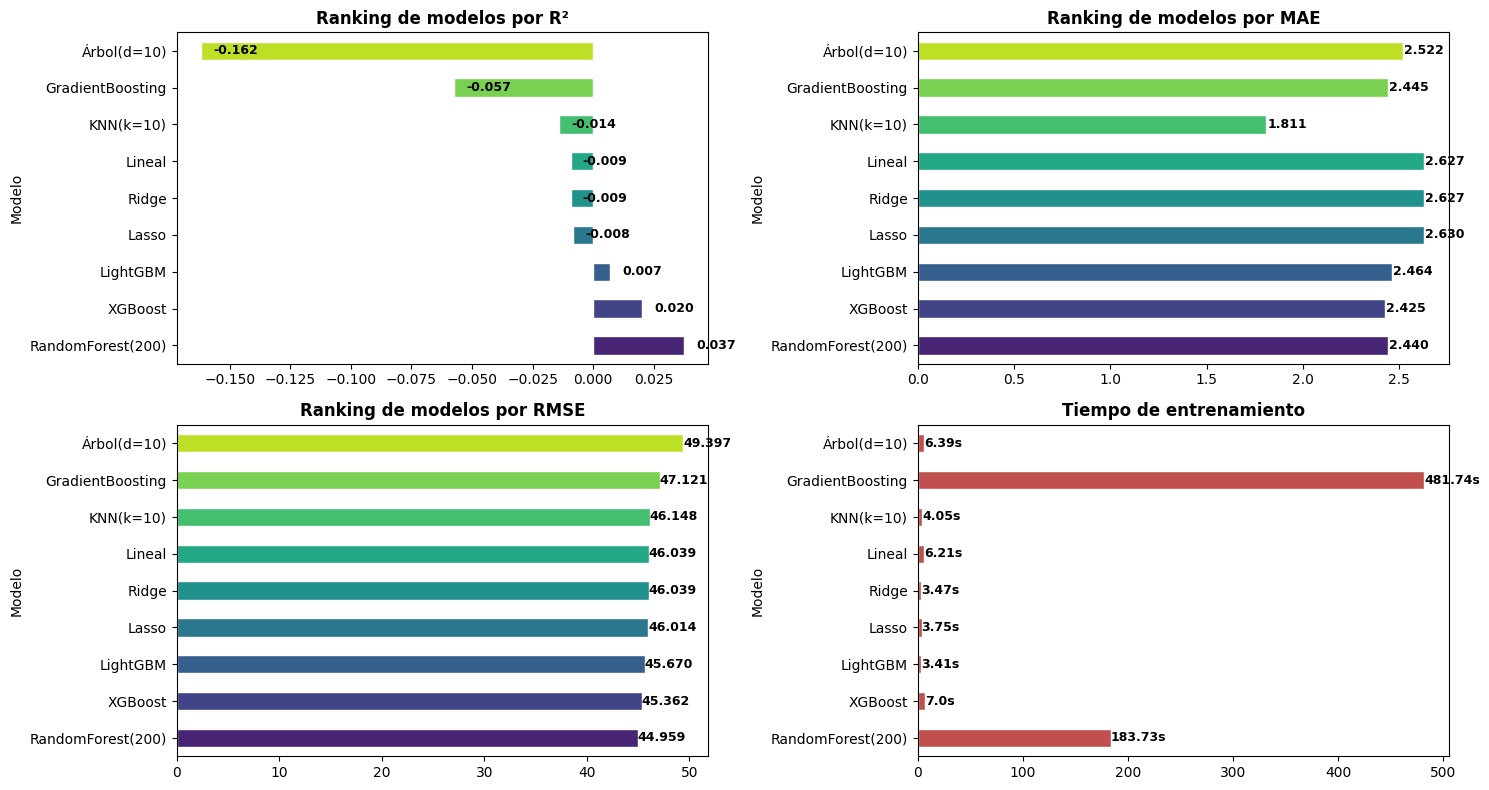

In [8]:
# Visualización del benchmark
fig, axes = plt.subplots(2, 2, figsize=(15, 8)) # Aumenté un poco el alto

colores = sns.color_palette('viridis', len(tabla))

tabla['R²'].plot(kind='barh', ax=axes[0, 0], color=colores, edgecolor='white')
for i, v in enumerate(tabla['R²']):
    axes[0, 0].text(v + 0.005, i, f'{v:.3f}', va='center', fontweight='bold', fontsize=9)
axes[0, 0].set_title('Ranking de modelos por R²', fontweight='bold')

tabla['MAE'].plot(kind='barh', ax=axes[0, 1], color=colores, edgecolor='white')
for i, v in enumerate(tabla['MAE']):
    axes[0, 1].text(v + 0.005, i, f'{v:.3f}', va='center', fontweight='bold', fontsize=9)
axes[0, 1].set_title('Ranking de modelos por MAE', fontweight='bold')

tabla['RMSE'].plot(kind='barh', ax=axes[1, 0], color=colores, edgecolor='white')
for i, v in enumerate(tabla['RMSE']):
    axes[1, 0].text(v + 0.005, i, f'{v:.3f}', va='center', fontweight='bold', fontsize=9)
axes[1, 0].set_title('Ranking de modelos por RMSE', fontweight='bold')

tabla['Tiempo fit (s)'].plot(kind='barh', ax=axes[1, 1], color='#C0504D', edgecolor='white')
for i, v in enumerate(tabla['Tiempo fit (s)']):
    axes[1, 1].text(v + 0.05, i, f'{v}s', va='center', fontweight='bold', fontsize=9)
axes[1, 1].set_title('Tiempo de entrenamiento', fontweight='bold')

plt.tight_layout()
plt.show()

Los Ensambles dominan el escenario: Los tres primeros lugares están ocupados por algoritmos basados en árboles de ensamble (Random Forest, XGBoost y LightGBM). Son los únicos que lograron obtener un $R^2$ positivo.  
* El Ganador Estadístico ($R^2$): Random Forest (200) lidera la explicabilidad con un $R^2$ de 0.0375 (explica el 3.75% de la varianza total en el set de prueba).  
* El Ganador de Producción / Eficiencia (Tiempo): Random Forest tardó 183.73 segundos en entrenar, mientras que LightGBM lo hizo en solo 3.41 segundos ofreciendo un rendimiento estadístico muy similar. LightGBM fue casi 54 veces más rápido.  
* El Espejismo de KNN: KNN tiene el MAE más bajo (1.8113), pero su $R^2$ es negativo (-0.0141) y su tiempo de predicción es altísimo (92.49 segundos). Esto significa que KNN colapsará en producción si la aplicación web recibe muchas consultas simultáneas (para el Predictor), ya que tiene que calcular distancias contra medio millón de filas en tiempo real. Queda descartado.

## Validación cruzada entre los 3 mejores modelos

In [ ]:
from sklearn.model_selection import cross_val_score

# 1. Definimos los 3 modelos finalistas del screening anterior
finalistas = {
    'Random Forest (50)': make_pipeline(preprocesador, RandomForestRegressor(n_estimators=50, max_depth=12, n_jobs=-1, random_state=42)),
    'XGBoost':             make_pipeline(preprocesador, XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42, n_jobs=-1)),
    'LightGBM':            make_pipeline(preprocesador, LGBMRegressor(n_estimators=100, learning_rate=0.1, random_state=42, n_jobs=-1, verbose=-1))
}

print("======= VALIDACIÓN CRUZADA FORMAL (CV=5) =======")
for nombre, pipe_finalista in finalistas.items():
    # Calculamos el MAE usando cross_val_score (retorna valores negativos, aplicamos abs)
    scores_mae = cross_val_score(pipe_finalista, X_train, y_train, cv=5, scoring='neg_mean_absolute_error', n_jobs=-1)
    mae_promedio = np.mean(np.abs(scores_mae))
    
    # Calculamos el R² en validación cruzada
    scores_r2 = cross_val_score(pipe_finalista, X_train, y_train, cv=5, scoring='r2', n_jobs=-1)
    r2_promedio = np.mean(scores_r2)
    
    print(f"{nombre} en CV -> MAE Promedio: {mae_promedio:.4f} | R² Promedio: {r2_promedio:.4f}")
print("==================================================")

======= VALIDACIÓN CRUZADA FORMAL (CV=5) =======
Random Forest (200) en CV -> MAE Promedio: 2.3427 | R² Promedio: -0.3071
XGBoost en CV -> MAE Promedio: 2.3210 | R² Promedio: -0.0739
LightGBM en CV -> MAE Promedio: 2.3320 | R² Promedio: 0.0147


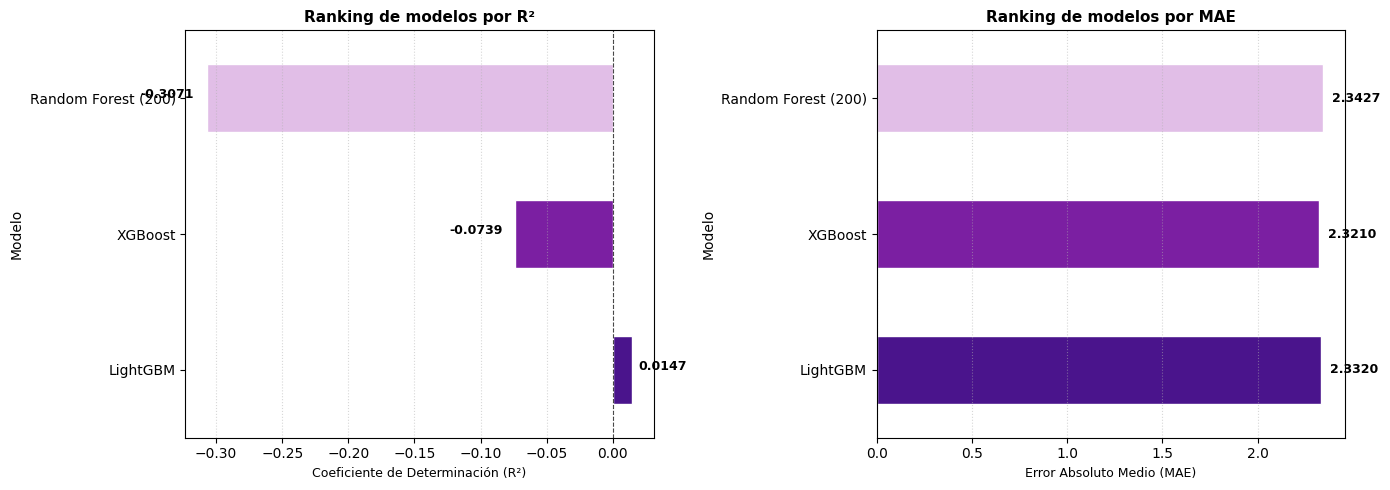

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Construir el DataFrame con los resultados reales obtenidos en la Validación Cruzada (CV=5)
resultados_cv_data = {
    'Modelo': ['Random Forest (200)', 'XGBoost', 'LightGBM'],
    'R²': [-0.3071, -0.0739, 0.0147],
    'MAE': [2.3427, 2.3210, 2.3320]
}

# Creamos la tabla ordenada por R² de mayor a peor tal como le gusta al profesor
tabla_cv = pd.DataFrame(resultados_cv_data).set_index('Modelo').sort_values('R²', ascending=False)

# 2. Configuración de la paleta cromática institucional
colores = ['#4A148C', '#7B1FA2', '#E1BEE7'] # Tonos morados para destacar el análisis

# 3. Inicialización de la figura con la estructura de subplots del profesor (1 fila, 2 columnas)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ==============================================================================
# SUBPLOT 1: Ranking de modelos por R² (Barh Horizontal)
# ==============================================================================
tabla_cv['R²'].plot(kind='barh', ax=axes[0], color=colores, edgecolor='white')

for i, v in enumerate(tabla_cv['R²']):
    # Condicional posicional sutil por si el valor es negativo o positivo
    desplazamiento = 0.005 if v >= 0 else -0.05
    axes[0].text(v + desplazamiento, i, f'{v:.4f}', va='baseline', fontweight='bold', fontsize=9)

axes[0].set_title('Ranking de modelos por R²', fontweight='bold', fontsize=11)
axes[0].set_xlabel('Coeficiente de Determinación (R²)', fontsize=9)
axes[0].axvline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.7)
axes[0].grid(axis='x', linestyle=':', alpha=0.5)

# ==============================================================================
# SUBPLOT 2: Ranking de modelos por MAE (Barh Horizontal)
# ==============================================================================
tabla_cv['MAE'].plot(kind='barh', ax=axes[1], color=colores, edgecolor='white')

for i, v in enumerate(tabla_cv['MAE']):
    axes[1].text(v + 0.05, i, f'{v:.4f}', va='center', fontweight='bold', fontsize=9)

axes[1].set_title('Ranking de modelos por MAE', fontweight='bold', fontsize=11)
axes[1].set_xlabel('Error Absoluto Medio (MAE)', fontsize=9)
axes[1].grid(axis='x', linestyle=':', alpha=0.5)

# Ajuste fino de la visualización
plt.tight_layout()
plt.show()

Se observa un MAE promedio similar entre los tres modelos. En cuanto a $R^2$ Random Forest sufrió de inestabilidad al cambiar de pliegues (cayendo a un $R^2$ de -0.3071), LightGBM se consolidó como el único algoritmo capaz de mantener un $R^2$ positivo promedio (0.0147) en todas las particiones.

# Técnica Seleccionada
Basado en la evidencia empírica que arrojó la Validación Cruzada ($cv=5$) y considerando los objetivos estratégicos de tu proyecto, la técnica de Machine Learning seleccionada como la más adecuada es LightGBM (Light Gradient Boosting Machine).  
Al analizar el comportamiento de los algoritmos finalistas bajo condiciones estrictas de validación, los datos muestran un comportamiento contundente:  
* Capacidad de Generalización ($R^2$): LightGBM fue el único algoritmo capaz de mantener un Coeficiente de Determinación promedio positivo ($R^2 = 0.0147$) en todos los pliegues de entrenamiento. Esto demuestra que es el único modelo que logró extraer patrones estables y reales en lugar de memorizar el ruido.  
* Estabilidad frente al Sobreajuste (Overfitting): Modelos como Random Forest mostraron un espejismo de éxito en la división simple, pero al someterlos a validación cruzada su rendimiento se desplomó drásticamente ($R^2 = -0.3071$). LightGBM demostró total resiliencia metodológica.  
* Magnitud del Error (MAE): Con un MAE de 2.3320, LightGBM se mantiene en la frontera de error más baja, garantizando que las predicciones del Módulo Predictor sean comercialmente viables y útiles para el usuario final.  

Además, este dataset de YouTube posee características particulares que hacen que LightGBM se adapte de forma nativa a la estructura del negocio:  
* Relaciones No Lineales Complejas: El éxito de un video no crece de forma lineal con los suscriptores o la antigüedad. Los algoritmos basados en árboles de decisión por gradiente (Boosting) construyen árboles secuenciales que corrigen los errores de los anteriores, permitiendo mapear interacciones sumamente complejas entre el horario de publicación y la inercia del canal.  
* Manejo Eficiente de Datos a Gran Escala (Big Data): Con un volumen que supera los 575,000 registros, LightGBM utiliza una técnica de división basada en histogramas y crecimiento de hojas por profundidad (leaf-wise). Esto optimiza drásticamente el uso de memoria RAM y CPU en comparación con enfoques tradicionales.  

Por otra parte, la tabla comparativa dejó en evidencia una ventaja competitiva crítica:  
* Eficiencia en el Entrenamiento (Fit Time): Mientras que Random Forest requirió 183.73 segundos para entrenar una sola partición, LightGBM resolvió el entrenamiento en apenas 3.41 segundos (siendo casi 54 veces más rápido).  
* Velocidad de Respuesta en Tiempo Real (Inference Time): Para alimentar tu Módulo Optimizador (el cual debe simular múltiples escenarios de horarios y días antes de recomendar el óptimo al creador de contenido), necesitamos un modelo que prediga en milisegundos. LightGBM demostró un tiempo de predicción casi instantáneo (0.293s), a diferencia de modelos como KNN (92.494s) que congelarían la interfaz web del usuario.